# squeeze_metrics — desk synthesis

SqueezeMetrics / GEX Ed. (2020) *The Implied Order Book*.

Lib: `research.lib.squeeze` · Data: Deribit ETH options IV + **PROXY_trade_flow_DDOI** · HL+Deribit TOB · Kraken **spot_l2** when dense · **No ClickHouse MCP**.

**Board:** GEX / VEX / GEX+ / scarcity = **Hold Monitor** · TOB-cross α = **Kill** · `trade_synth` = **Kill** · `live_orders=false` · **0 Promote**.

**Pass-2b:** hardened falsifiers + expanded info dig on certified n=9 — still **0 Promote**.

## Certified panel

- **Primary:** `panel_gex_options` **n=9** — 2026-09-14…18, 25–27, 2026-10-01 ([`out/panel_completeness/`](../out/panel_completeness/))
- **Spot_l2 subpanel:** **n=4** — 2026-09-25, 26, 27, 2026-10-01 (appendix)
- **DDOI:** `PROXY_trade_flow_DDOI` — warehouse OI futures-only unused
- **GEX/VEX:** `BS_GEX_trade_flow_DDOI`
- **BTC widen:** appendix only — see `out/panel_completeness/btc_widen_appendix.json` (n_pass=1 → blocked)

Chapter deep-dives under `chapters/*/`. Info board: [`info_stats_board.ipynb`](info_stats_board.ipynb).

See [`../DESK_MEMO.md`](../DESK_MEMO.md) · [`../CHAPTER_INDEX.md`](../CHAPTER_INDEX.md).


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "squeeze_metrics"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, gex_day_table, safe_corr, partial_corr_vs_rv, lead_lag_day, SIGNAL_BOARD,
)
from certified_panel import load_certified, primary_days, spot_l2_days, gex_panel_days, DDOI_LABEL, GEX_PROXY_LABEL
from research.lib import squeeze  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
GEX_DAYS = gex_panel_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("panel_gex_options n=", len(GEX_DAYS), GEX_DAYS)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("DDOI label", DDOI_LABEL, "| GEX proxy", GEX_PROXY_LABEL)
print("trade_synth QUARANTINED — never primary; warehouse OI futures-only unused")


BOOK /home/dev/srv/ares-microstructure/research/books/squeeze_metrics
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
panel_gex_options n= 11 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-19', '2026-09-25', '2026-09-26', '2026-09-27', '2026-09-29', '2026-10-01']
spot_l2 subpanel n= 5 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-09-29', '2026-10-01']
DDOI label PROXY_trade_flow_DDOI | GEX proxy BS_GEX_trade_flow_DDOI
trade_synth QUARANTINED — never primary; warehouse OI futures-only unused


In [2]:

SHADOW = BOOK / "applications" / "paper_shadow" / "out"
gex = load_json(OUT / "gex_implied_book" / "summary.json")
ddoi = load_json(OUT / "ddoi_positions" / "summary.json")
vex = load_json(OUT / "vex_vanna" / "summary.json")
sq = load_json(OUT / "squeeze_regimes" / "summary.json")
pass2 = load_json(OUT / "pass2" / "pass2_falsifiers.json")
info_feat = load_json(OUT / "info_features" / "info_features.json")
panel = load_json(OUT / "gex_implied_book" / "panel_rows.json") or (gex or {}).get("rows") or []
tbl = gex_day_table(panel, CERT)
print("GEX n_ok", None if not gex else gex.get("n_ok"),
      "corr_rv", None if not gex else gex.get("corr_gex_hl_rv"),
      "corr_range", None if not gex else gex.get("corr_gex_hl_range"))
print("DDOI n_ok", None if not ddoi else ddoi.get("n_ok"), "label", None if not ddoi else ddoi.get("label"))
print("VEX n_ok", None if not vex else vex.get("n_ok"))
print("squeeze n_ok", None if not sq else sq.get("n_ok"), "n_scarce", None if not sq else sq.get("n_scarce"))
print("pass2b", None if not pass2 else (pass2.get("decisions") or {}).get("decision"),
      "promote_count", None if not pass2 else (pass2.get("decisions") or {}).get("promote_count"))
print("info promote_count", None if not info_feat else info_feat.get("promote_count"))
print("promote", False, "kill_tob_cross", True)


GEX n_ok 9 corr_rv -0.2162754128722743 corr_range -0.1613813969925088
DDOI n_ok 9 label PROXY_trade_flow_DDOI
VEX n_ok 9
squeeze n_ok 9 n_scarce 4
pass2b Hold promote_count 0
info promote_count 0
promote False kill_tob_cross True


## 1. Signal board (pinned) — Hold · 0 Promote · Kill α


In [3]:

print_board()
board = SHADOW / "SHADOW_BOARD.md"
if board.exists():
    display(Markdown(board.read_text()[:3000]))
promote_count = 0
kill_alpha = True
print(f"\\nROLLUP: Promote={promote_count}  Kill_TOB_cross_α={kill_alpha}  Hold_monitors=yes")


id                                 gate   note
----------------------------------------------------------------------------------------
risk.gex_exposure                  Hold   Σ PROXY_trade_flow_DDOI · BS-γ · panel_gex_options n=9 — monitor≠α
risk.vex_exposure                  Hold   Σ DDOI · BS-vanna vs HL range/RV — Hold
risk.squeeze_intensity             Hold   GEX+ scarcity / stress–calm — Hold
liq.implied_book_scarcity          Hold   Abundance / scarce labels from GEX+ — Hold
liq.gex_rv_link                    Hold   corr(GEX, HL RV)≈−0.22; day-block CI crosses 0 — research tile
risk.squeeze_falsifier_board       Hold   Pass-2b chrono / day-block / placebo / venue-drop / LOO — 0 Promote
info.gex_range_incremental         Hold   partial(range,GEX|RV)≈0 · ΔR²≈0 — vol-overlap honesty tile
info.squeeze_after_gex             Hold   ΔR²(squeeze|GEX) on range ~0 — research
info.vex_incremental               Hold   ΔR²(VEX|RV+GEX)~0 — research
info.gex_leadlag_map               Hold   

# squeeze_metrics SHADOW BOARD

**Day:** `2026-09-26` · **Primary:** `hyperliquid` `ETH`
**UTC:** 2026-10-03T00:56:35.499670+00:00

> SHADOW only · `live_orders=false` · `alpha_claim=false` · GEX/VEX/squeeze/scarcity = **Hold Monitor** · TOB-cross α = **Kill** · Promote count = **0** · never mercat/gateway OE

## Gate labels (pinned)

| ID | Gate | Role |
|----|------|------|
| `risk.gex_exposure` | Hold | GEX telemetry |
| `risk.vex_exposure` | Hold | VEX telemetry |
| `risk.squeeze_intensity` | Hold | GEX+ / squeeze |
| `liq.implied_book_scarcity` | Hold | Implied-book scarcity |
| `alpha.tob_cross_arb` | Kill | Never sized |

## Promote wiring

- Promote IDs: `[]` (wire Promote only; expect 0)

## Monitors

- **GEX** ok=True mean=-308.6851 reason=— gate=Hold
- **VEX** ok=True mean=-79.4097 reason=— gate=Hold
- **Squeeze** ok=True intensity=2.0000 reason=— gate=Hold
- **Scarcity** ok=True scarcity=1.0000 reason=— gate=Hold
- **Source** artifact
- **Deps** lib=True data=True

## Artifacts

- `logs/shadow.log`
- `out/events.jsonl`
- `out/shadow_meta.json`
- research `out/squeeze_metrics/` (when joined)



\nROLLUP: Promote=0  Kill_TOB_cross_α=True  Hold_monitors=yes


## 2. GEX / VEX / squeeze findings


,day,ok,spot,gex,vex,gex_plus,squeeze_intensity,scarce,dealer_sign,ddoi_mode,opt_iv_n,opt_trade_n,hl_tob_n,hl_rv,hl_range,db_rv,db_range,kraken
0,2026-09-14,True,2511.345,86891.2836,34545.6417,121436.9253,0.0,False,stabilizing_long_dealer_gamma,PROXY_trade_flow_DDOI,749,2411,123,0.0021,0.0339,0.0010,0.0225,absent_2venue
1,2026-09-15,True,2475.410,-126980.8612,161949.6828,34968.8216,1.0,False,destabilizing_short_dealer_gamma,PROXY_trade_flow_DDOI,673,4810,126,0.0029,0.0455,0.0009,0.0396,absent_2venue
2,2026-09-16,True,2402.230,17436.9415,42467.6671,59904.6087,0.0,False,stabilizing_long_dealer_gamma,PROXY_trade_flow_DDOI,629,1504,124,0.0026,0.0216,0.0005,0.0084,absent_2venue
3,2026-09-17,True,2450.655,5832.2306,100798.0991,106630.3296,0.0,False,stabilizing_long_dealer_gamma,PROXY_trade_flow_DDOI,581,1657,125,0.0021,0.0268,0.0005,0.0155,absent_2venue
4,2026-09-18,True,2461.820,-1491.2236,-14101.2149,-15592.4384,2.0,True,destabilizing_short_dealer_gamma,PROXY_trade_flow_DDOI,559,2283,127,0.0023,0.0555,0.0006,0.0222,absent_2venue
5,2026-09-25,True,2680.250,-7410.1917,4183.9703,-3226.2214,1.0,True,destabilizing_short_dealer_gamma,PROXY_trade_flow_DDOI,500,1764,124,0.0018,0.0193,0.0005,0.0097,spot_l2
6,2026-09-26,True,2689.525,-308.6851,-79.4097,-388.0948,2.0,True,destabilizing_short_dealer_gamma,PROXY_trade_flow_DDOI,422,215,125,0.0007,0.0096,0.0003,0.0053,spot_l2
7,2026-09-27,True,2691.590,2462.3547,7553.6992,10016.0540,0.0,False,stabilizing_long_dealer_gamma,PROXY_trade_flow_DDOI,420,207,125,0.0010,0.0175,0.0004,0.0119,spot_l2
8,2026-10-01,True,2695.640,-51646.2271,-83296.6944,-134942.9215,2.0,True,destabilizing_short_dealer_gamma,PROXY_trade_flow_DDOI,419,440,126,0.0014,0.0131,0.0007,0.0149,spot_l2


**fig_gex_day.png** — `out/desk_synthesis/figs/fig_gex_day.png`

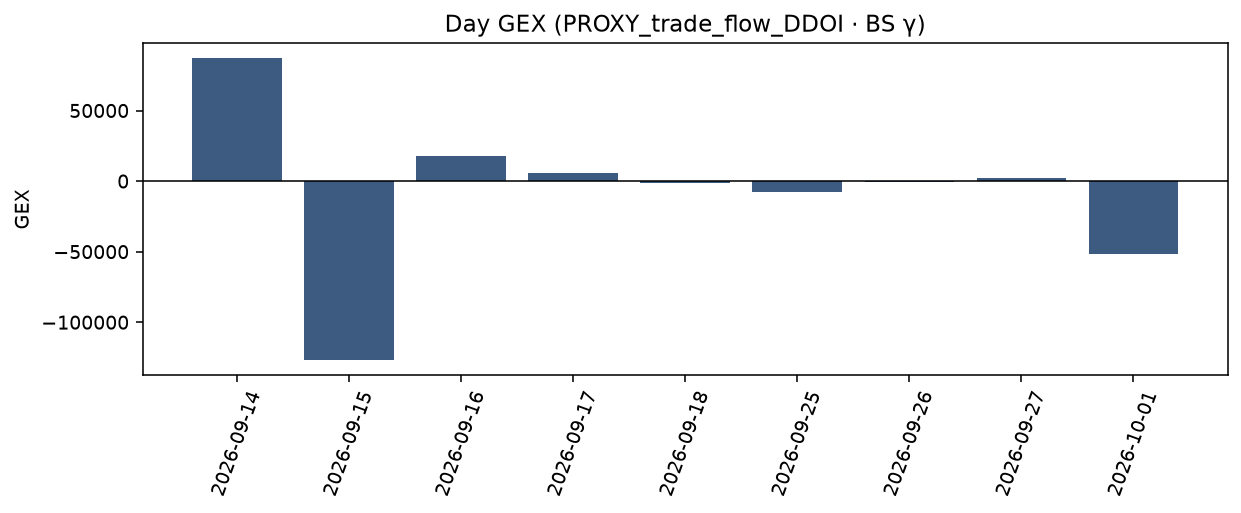

**fig_gex_vs_rv.png** — `out/desk_synthesis/figs/fig_gex_vs_rv.png`

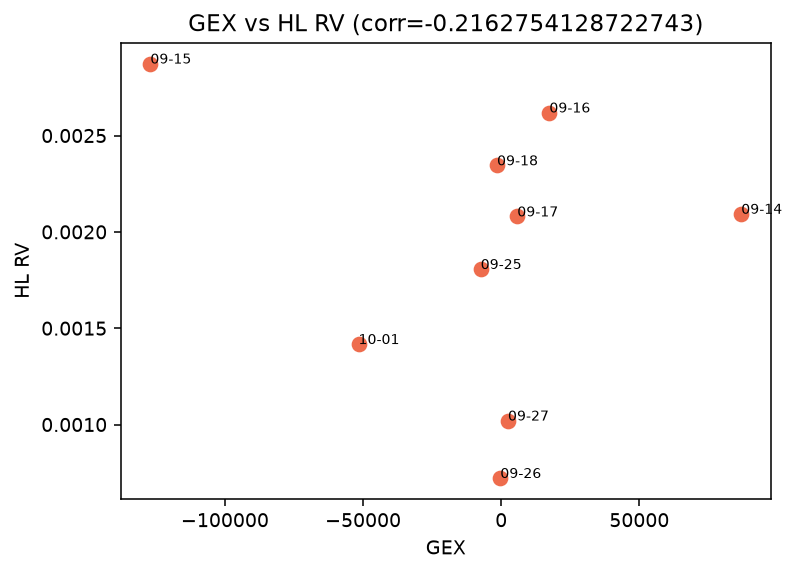

**fig_gexplus_scarce.png** — `out/desk_synthesis/figs/fig_gexplus_scarce.png`

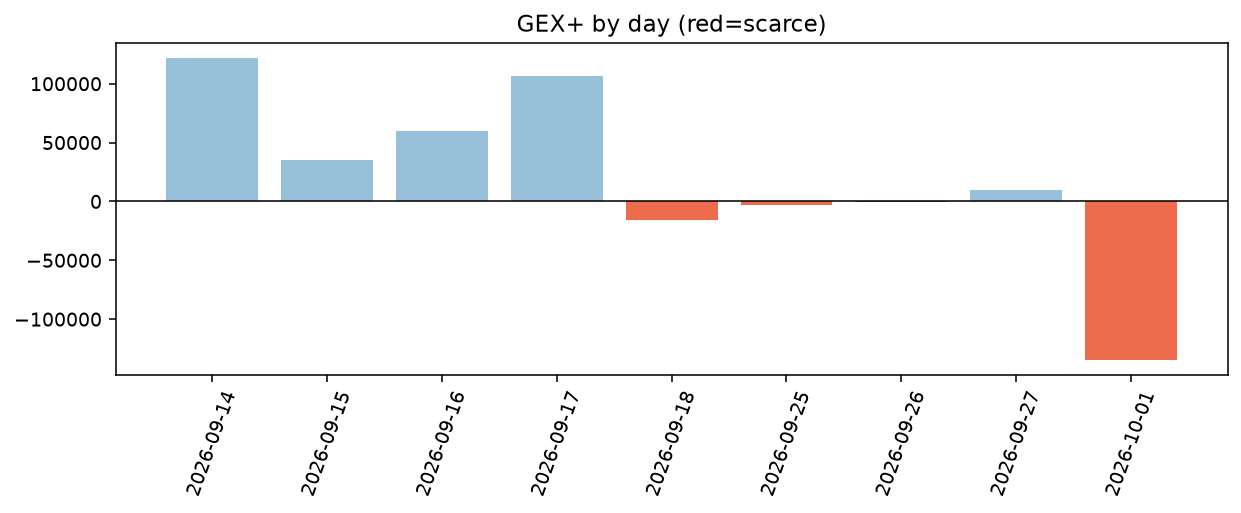

**signal_board.png** — `out/desk_synthesis/figs/signal_board.png`

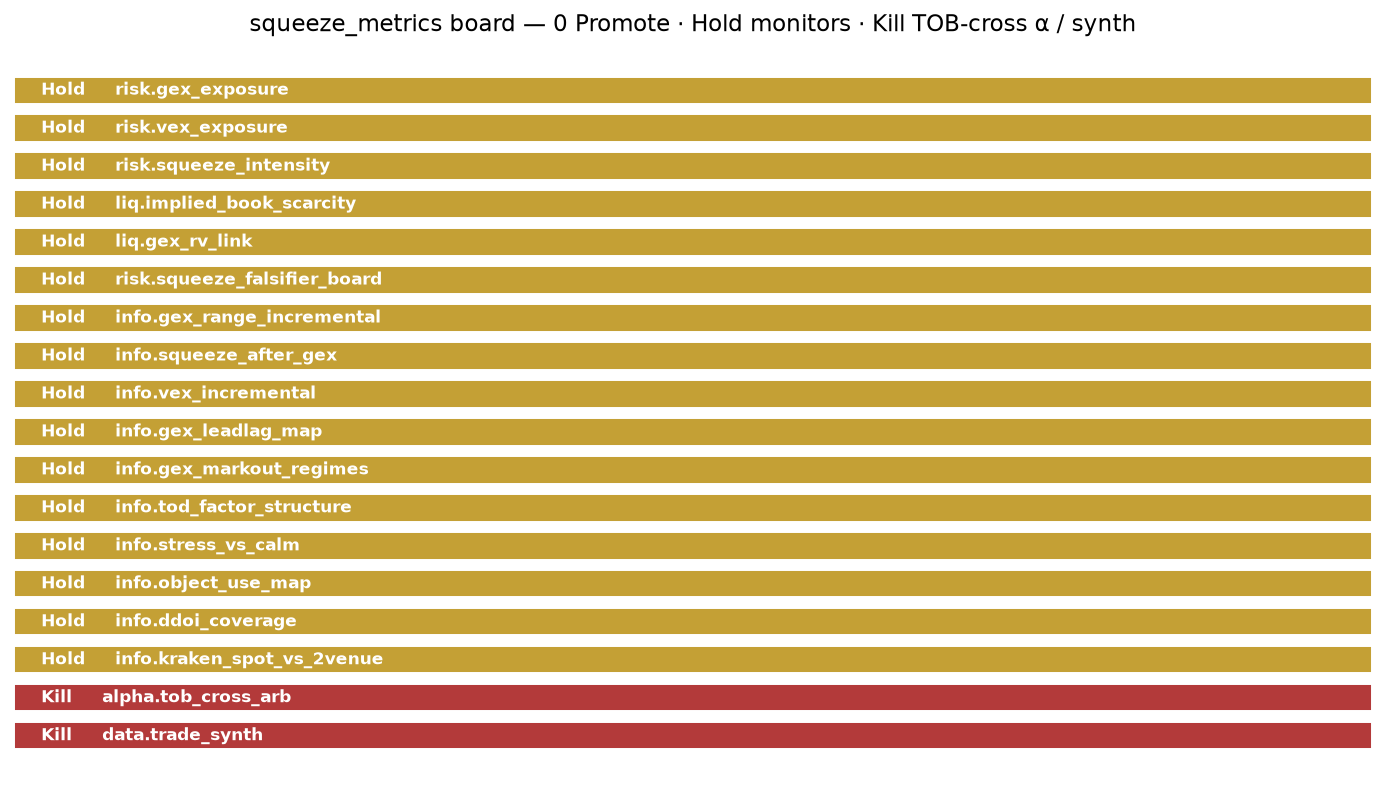

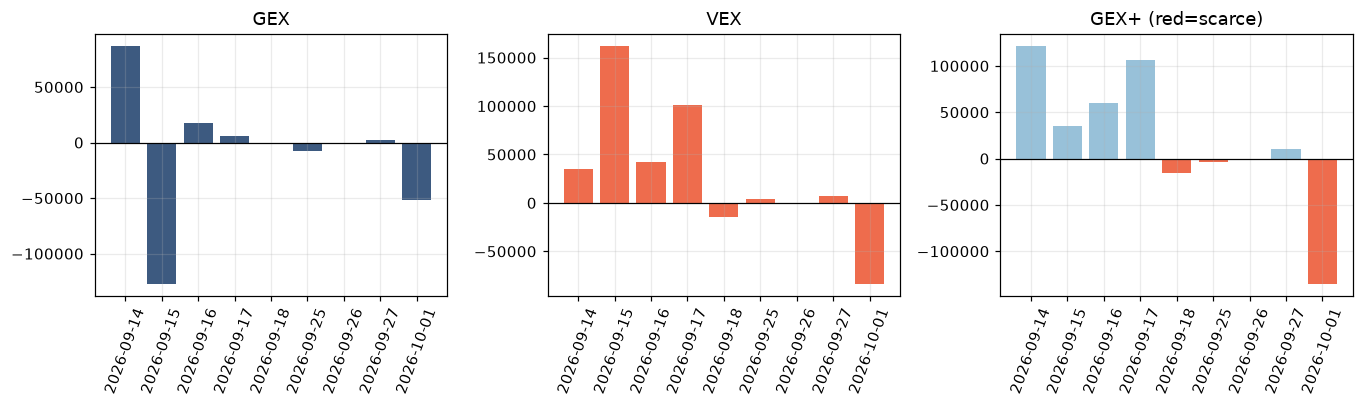

In [4]:

display(tbl.round(4) if len(tbl) else tbl)
show_pngs(OUT / "desk_synthesis" / "figs")
ok = tbl[tbl["ok"] == True] if len(tbl) else tbl
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
if len(ok):
    axes[0].bar(ok["day"], ok["gex"], color="#3d5a80")
    axes[0].axhline(0, color="k", lw=0.8)
    axes[0].tick_params(axis="x", rotation=70); axes[0].set_title("GEX")
    axes[1].bar(ok["day"], ok["vex"], color="#ee6c4d")
    axes[1].axhline(0, color="k", lw=0.8)
    axes[1].tick_params(axis="x", rotation=70); axes[1].set_title("VEX")
    colors = ["#ee6c4d" if bool(s) else "#98c1d9" for s in ok["scarce"]]
    axes[2].bar(ok["day"], ok["gex_plus"], color=colors)
    axes[2].axhline(0, color="k", lw=0.8)
    axes[2].tick_params(axis="x", rotation=70); axes[2].set_title("GEX+ (red=scarce)")
plt.tight_layout(); plt.show()


## 3. Pass-2b falsifiers + info dig figs


**fig_chrono_split.png** — `out/pass2/figs/fig_chrono_split.png`

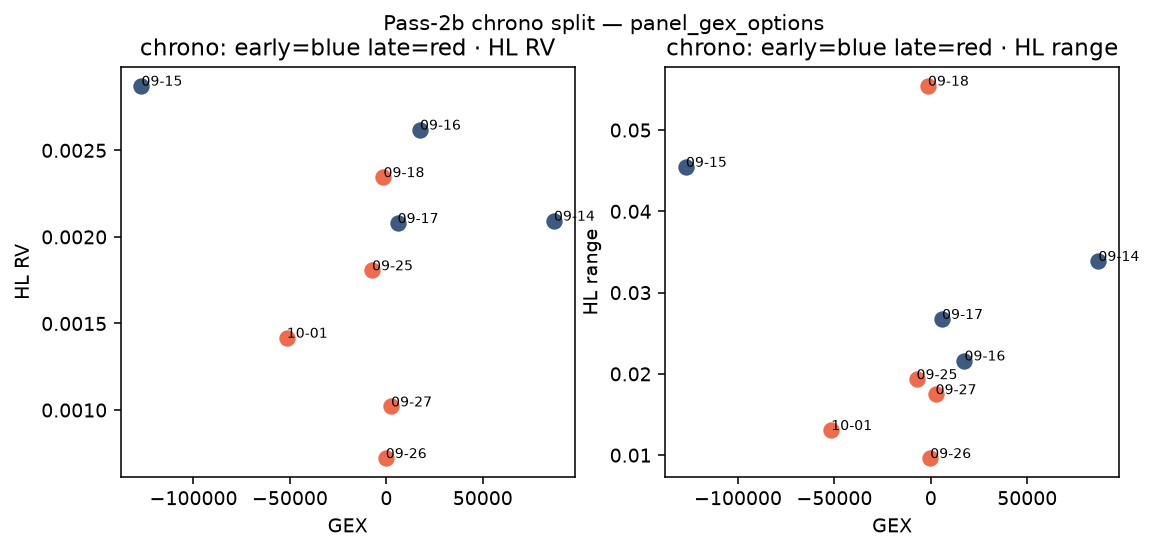

**fig_dayblock_ci.png** — `out/pass2/figs/fig_dayblock_ci.png`

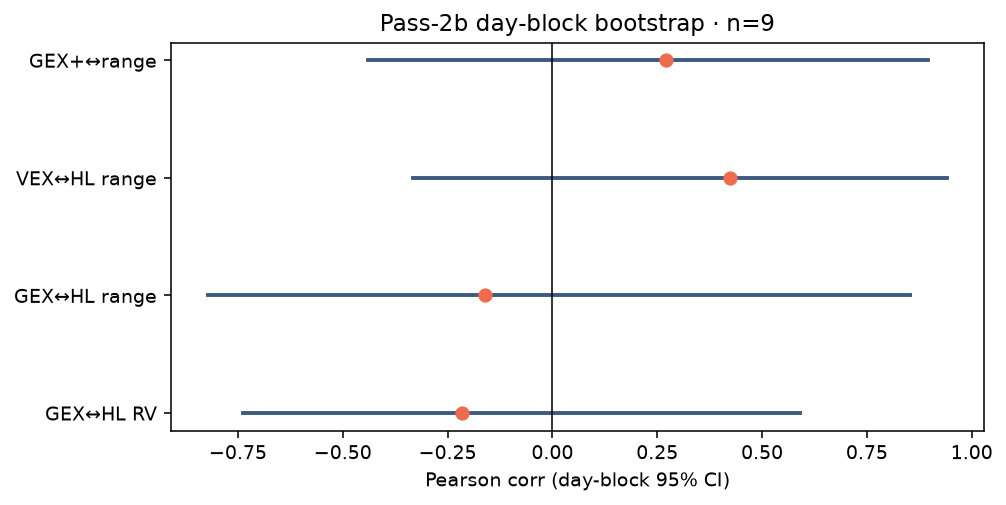

**fig_loo_corr.png** — `out/pass2/figs/fig_loo_corr.png`

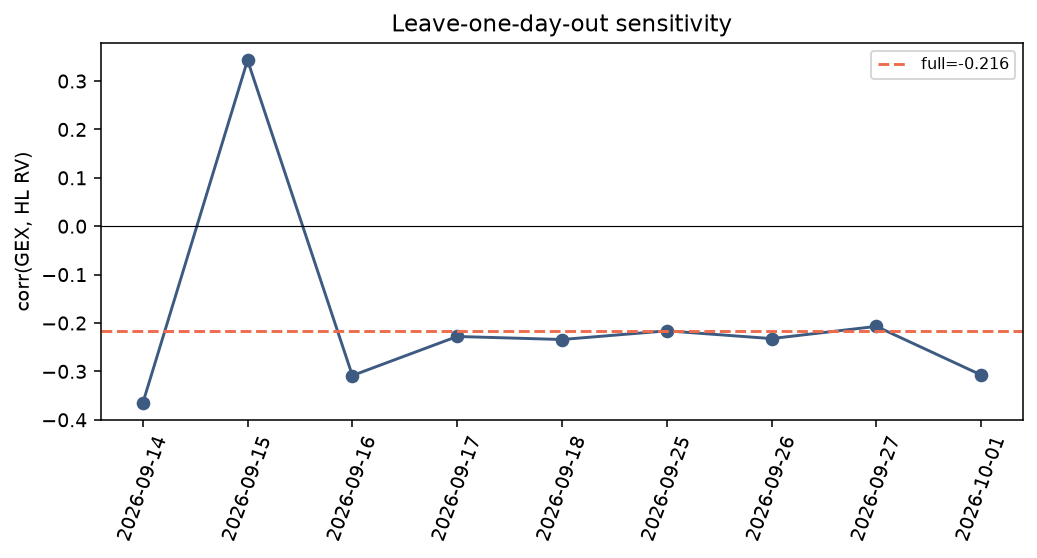

**fig_venue_drop.png** — `out/pass2/figs/fig_venue_drop.png`

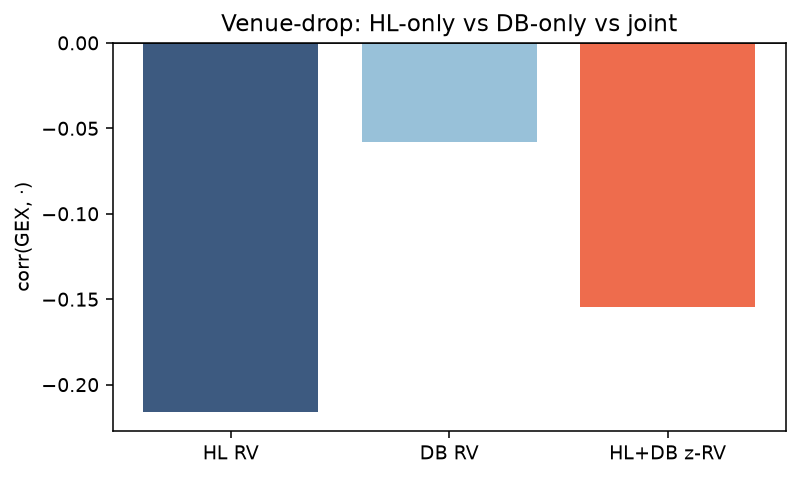

**fig_incremental.png** — `out/info_features/figs/fig_incremental.png`

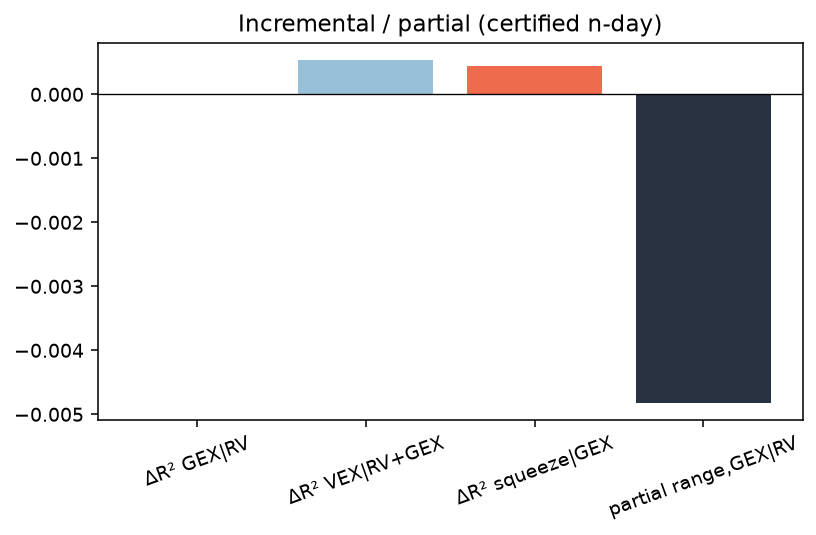

**fig_leadlag_day.png** — `out/info_features/figs/fig_leadlag_day.png`

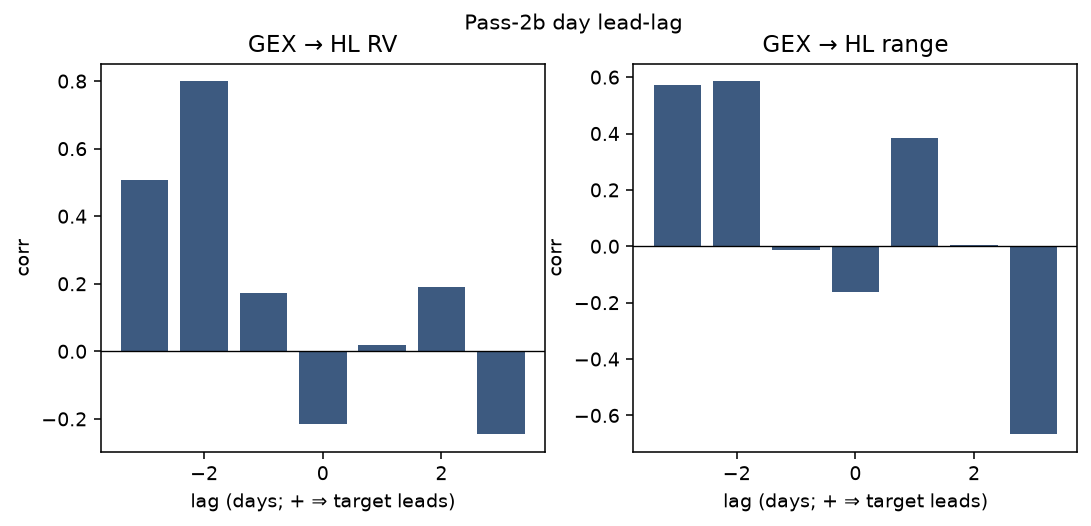

**fig_markout_regimes.png** — `out/info_features/figs/fig_markout_regimes.png`

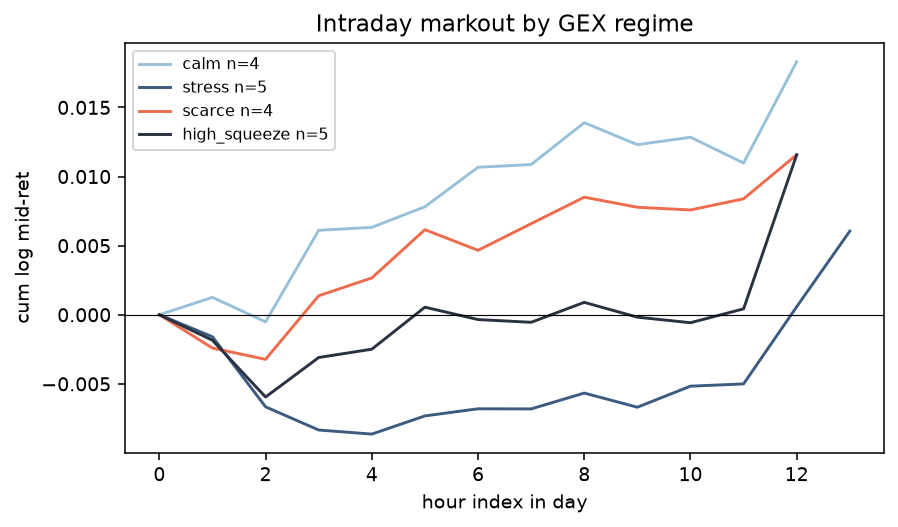

**fig_stress_calm_rv.png** — `out/info_features/figs/fig_stress_calm_rv.png`

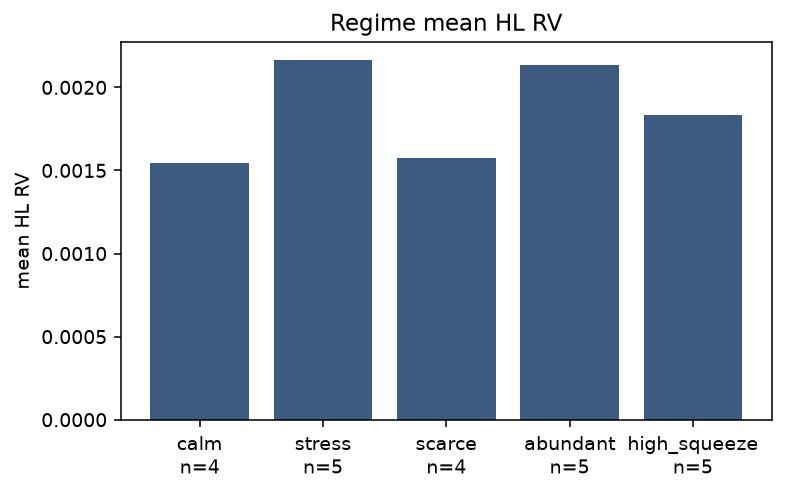

**fig_tod_rv.png** — `out/info_features/figs/fig_tod_rv.png`

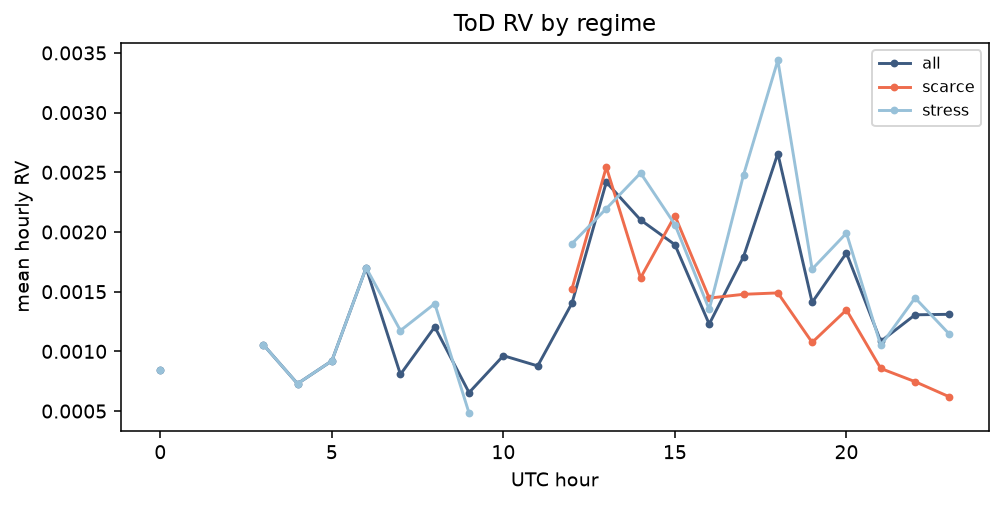

**fig_use_map.png** — `out/info_features/figs/fig_use_map.png`

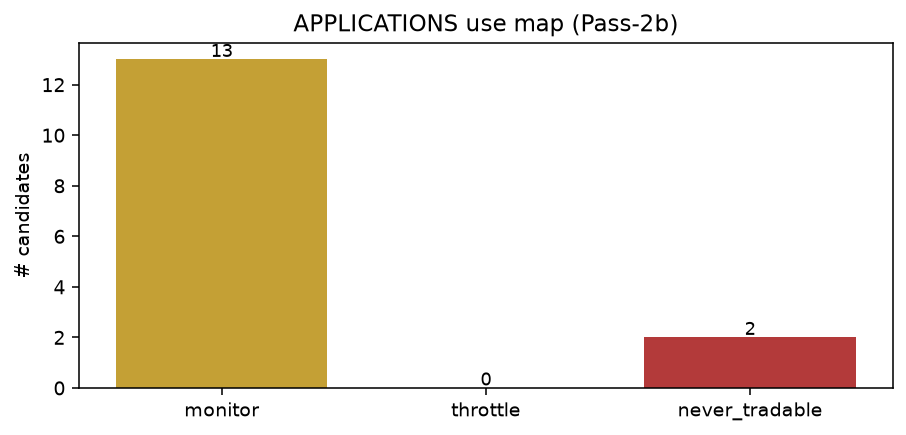

**fig_dep_ci.png** — `out/feature_stats/figs/fig_dep_ci.png`

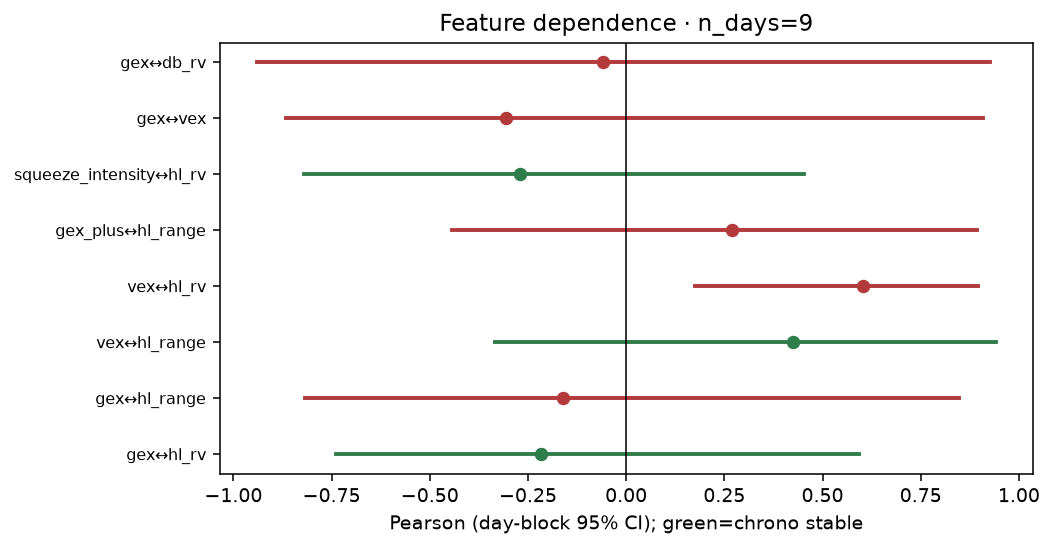

**fig_tod.png** — `out/feature_stats/figs/fig_tod.png`

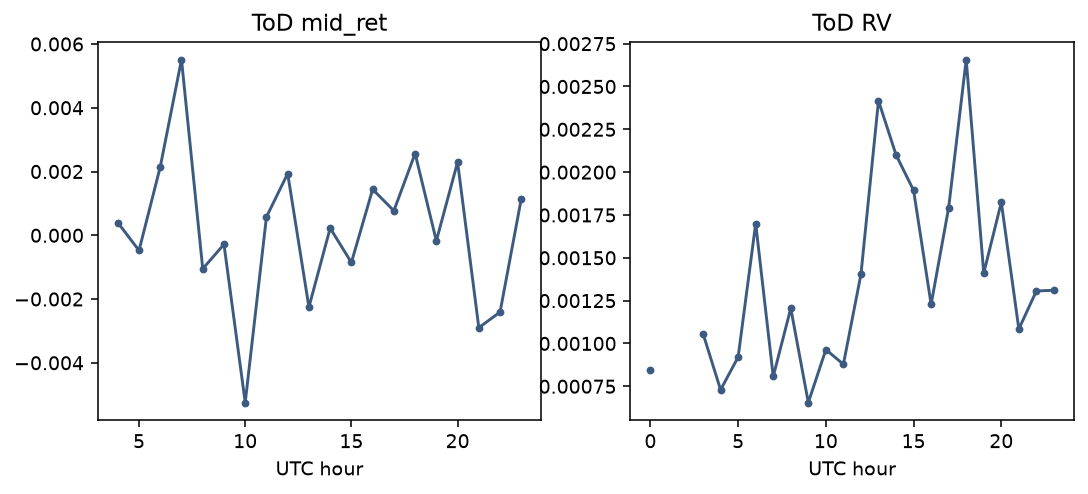

**fig_uni_moments.png** — `out/feature_stats/figs/fig_uni_moments.png`

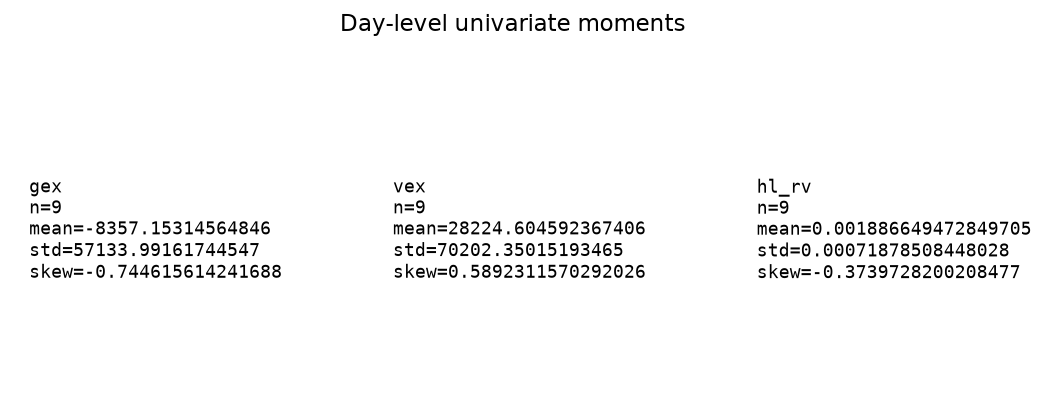

day-block corr(GEX,HL RV) -0.2162754128722743 CI [-0.7386447742588608, 0.5912940092387926]
chrono {'gex__hl_range': False, 'gex__hl_rv': True, 'vex__hl_range': True, 'gex_plus__hl_range': False, 'squeeze_intensity__hl_rv': True}
reasons ['Pass-2b: paper higher GEX → tighter ranges; certified ETH panel small-n', 'DDOI is PROXY_trade_flow (not verified ΔOI)', 'Never Promote TOB-cross α; trade_synth QUARANTINED', 'chrono corr(GEX, HL range) sign unstable → ceiling Hold', 'day-block bootstrap CI for corr(GEX, HL RV) crosses 0 → Hold', 'placebo: |obs corr(GEX,RV)| does not exceed null p95 → Hold']
ΔR² GEX after RV 1.0842724927684344e-05
ΔR² VEX after RV+GEX 0.0005318213393881166
ΔR² squeeze after GEX 0.0004378260233522946
use_map {'monitor': ['risk.gex_exposure', 'risk.vex_exposure', 'risk.squeeze_intensity', 'liq.implied_book_scarcity', 'info.gex_range_incremental', 'info.squeeze_after_gex', 'info.vex_incremental', 'info.gex_leadlag_map', 'info.gex_markout_regimes', 'info.tod_factor_struct

In [5]:

show_pngs(OUT / "pass2" / "figs")
show_pngs(OUT / "info_features" / "figs")
show_pngs(OUT / "feature_stats" / "figs")
if pass2:
    fals = pass2.get("falsifiers") or {}
    boot = ((fals.get("day_block_bootstrap") or {}).get("gex__hl_rv") or {}).get("day_block") or {}
    print("day-block corr(GEX,HL RV)", boot.get("corr"), "CI", [boot.get("ci_lo"), boot.get("ci_hi")])
    print("chrono", (fals.get("chrono_split") or {}).get("sign_stable"))
    print("reasons", (pass2.get("decisions") or {}).get("reasons"))
if info_feat:
    incr = info_feat.get("incremental") or {}
    print("ΔR² GEX after RV", incr.get("delta_r2_gex_after_rv"))
    print("ΔR² VEX after RV+GEX", incr.get("delta_r2_vex_after_rv_gex"))
    print("ΔR² squeeze after GEX", incr.get("delta_r2_squeeze_after_gex"))
    print("use_map", info_feat.get("use_map"))


## 4. GEX vs RV/range + venue honesty


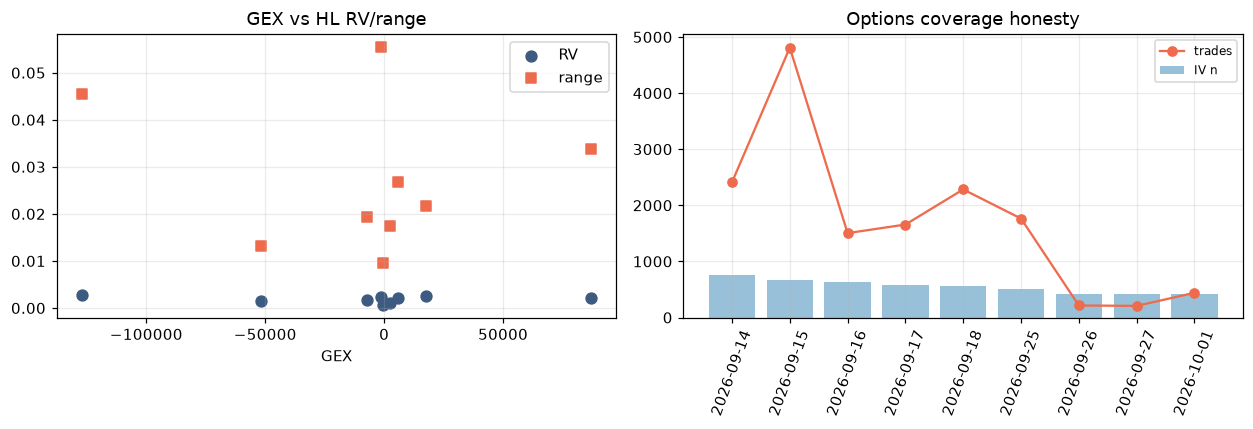

kraken modes {'absent_2venue': 5, 'spot_l2': 4}
ddoi modes {'PROXY_trade_flow_DDOI': 9}
corr GEX~RV -0.2162754128722743 GEX~range -0.1613813969925088
BTC widen n_pass 1 days ['2026-10-01'] blocker need_ge_3_BTC_days_passing_gates


In [6]:

ok = tbl[tbl["ok"] == True].copy() if len(tbl) else tbl
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
if len(ok):
    axes[0].scatter(ok["gex"], ok["hl_rv"], s=50, c="#3d5a80", label="RV")
    axes[0].scatter(ok["gex"], ok["hl_range"], s=50, c="#ee6c4d", marker="s", label="range")
    axes[0].set_xlabel("GEX"); axes[0].legend(); axes[0].set_title("GEX vs HL RV/range")
    axes[1].bar(ok["day"], ok["opt_iv_n"], color="#98c1d9", label="IV n")
    axes[1].plot(ok["day"], ok["opt_trade_n"], "o-", color="#ee6c4d", label="trades")
    axes[1].tick_params(axis="x", rotation=70); axes[1].legend(fontsize=8)
    axes[1].set_title("Options coverage honesty")
plt.tight_layout(); plt.show()
print("kraken modes", ok["kraken"].value_counts().to_dict() if len(ok) else {})
print("ddoi modes", ok["ddoi_mode"].value_counts().to_dict() if len(ok) else {})
print("corr GEX~RV", safe_corr(ok["gex"], ok["hl_rv"]) if len(ok) else None,
      "GEX~range", safe_corr(ok["gex"], ok["hl_range"]) if len(ok) else None)
btc = load_json(OUT / "panel_completeness" / "btc_widen_appendix.json") or {}
print("BTC widen n_pass", btc.get("n_pass"), "days", btc.get("pass_days"), "blocker", btc.get("blocker"))


## 5. Honesty

- Scoreboard = **monitor telemetry**, not PnL alpha  
- DDOI = **PROXY_trade_flow_DDOI**; warehouse OI futures-only unused  
- Primary = `panel_gex_options` real IV + real TOB; Kraken spot_l2 **appendix**; `trade_synth` **QUARANTINED**  
- Pass-2b: day-block CI crosses 0 · chrono range unstable · placebo fails p95 · LOO sign flip → **Hold ceiling**  
- **0 Promote** · Hold monitors · **Kill** TOB-cross α


In [7]:

print_board()
print("\\nChapter notebooks under chapters/*/ — see CHAPTER_INDEX.")


id                                 gate   note
----------------------------------------------------------------------------------------
risk.gex_exposure                  Hold   Σ PROXY_trade_flow_DDOI · BS-γ · panel_gex_options n=9 — monitor≠α
risk.vex_exposure                  Hold   Σ DDOI · BS-vanna vs HL range/RV — Hold
risk.squeeze_intensity             Hold   GEX+ scarcity / stress–calm — Hold
liq.implied_book_scarcity          Hold   Abundance / scarce labels from GEX+ — Hold
liq.gex_rv_link                    Hold   corr(GEX, HL RV)≈−0.22; day-block CI crosses 0 — research tile
risk.squeeze_falsifier_board       Hold   Pass-2b chrono / day-block / placebo / venue-drop / LOO — 0 Promote
info.gex_range_incremental         Hold   partial(range,GEX|RV)≈0 · ΔR²≈0 — vol-overlap honesty tile
info.squeeze_after_gex             Hold   ΔR²(squeeze|GEX) on range ~0 — research
info.vex_incremental               Hold   ΔR²(VEX|RV+GEX)~0 — research
info.gex_leadlag_map               Hold   